In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, precision_recall_curve, f1_score
)
from xgboost import XGBClassifier
import pickle, json, warnings
warnings.filterwarnings('ignore')

print('All imports successful')

All imports successful


In [3]:
df = pd.read_csv('/content/drive/MyDrive/PS_20174392719_1491204439457_log.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (6362620, 11)

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# -------------------------------------------------------------------------
# SCALE FIX: Convert all monetary columns from USD to INR
#
# PaySim dataset uses USD. Indian users enter amounts in INR.
# Instead of converting user input to USD at runtime (which causes
# scale mismatch — ₹1000 = $10 which the model rarely saw in training),
# we convert the entire training dataset to INR once here.
#
# Result: model learns INR-scale patterns → backend sends INR directly
#         → no runtime conversion needed → no scale mismatch ever.
#
# IMPORTANT: This rate must exactly match USD_TO_INR in backend/config.py
# -------------------------------------------------------------------------
INR_PER_USD = 96.31   # keep in sync with config.py USD_TO_INR

monetary_cols = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest'
]

df[monetary_cols] = df[monetary_cols] * INR_PER_USD

print(f'All monetary columns scaled to INR (x{INR_PER_USD})')
print('\nSample INR-scale statistics:')
print(df[monetary_cols].describe())
print('\nVerify: mean amount should now be in lakhs range, not thousands of USD')

All monetary columns scaled to INR (x96.31)

Sample INR-scale statistics:
             amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
count  6.362620e+06   6.362620e+06    6.362620e+06    6.362620e+06   
mean   1.732250e+07   8.031128e+07    8.235600e+07    1.060086e+08   
std    5.815759e+07   2.781667e+08    2.816151e+08    3.273750e+08   
min    0.000000e+00   0.000000e+00    0.000000e+00    0.000000e+00   
25%    1.289549e+06   0.000000e+00    0.000000e+00    0.000000e+00   
50%    7.210917e+06   1.368372e+06    0.000000e+00    1.278088e+07   
75%    2.010197e+07   1.033552e+07    1.389353e+07    9.082387e+07   
max    8.903428e+09   5.738635e+09    4.775535e+09    3.428789e+10   

       newbalanceDest  
count    6.362620e+06  
mean     1.179794e+08  
std      3.538554e+08  
min      0.000000e+00  
25%      0.000000e+00  
50%      2.067404e+07  
75%      1.070880e+08  
max      3.430363e+10  

Verify: mean amount should now be in lakhs range, not thousands of USD


In [6]:
print(df.info())

print('\nFraud Distribution:')
print(df['isFraud'].value_counts())
print(f"Fraud Percentage: {df['isFraud'].mean()*100:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

Fraud Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Percentage: 0.13%


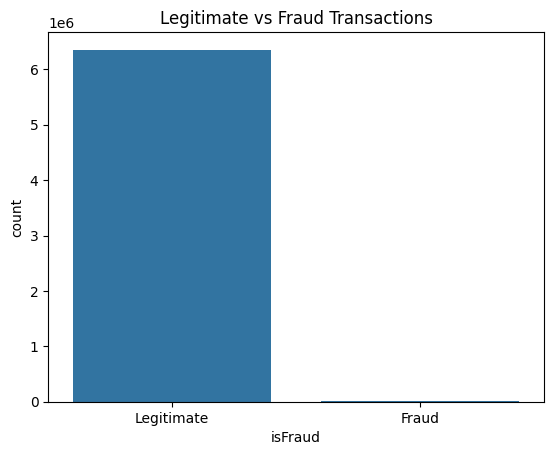

In [7]:
sns.countplot(x='isFraud', data=df)
plt.title('Legitimate vs Fraud Transactions')
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()

In [8]:
# This confirms fraud ONLY appears in TRANSFER and CASH_OUT
print(df.groupby('type')['isFraud'].sum())
print('\nFraud by type percentage:')
print(df.groupby('type')['isFraud'].mean() * 100)

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

Fraud by type percentage:
type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64


In [9]:
# Drop unnecessary columns
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
print('Shape after dropping name/flag cols:', df.shape)

# -------------------------------------------------------------------------
# FIX 1: Keep only TRANSFER and CASH_OUT
# Fraud in PaySim ONLY occurs in these two types.
# -------------------------------------------------------------------------
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
print('Shape after filtering to TRANSFER/CASH_OUT:', df.shape)
print('\nFraud distribution after filter:')
print(df['isFraud'].value_counts())
print(f"Fraud %: {df['isFraud'].mean()*100:.4f}%")

Shape after dropping name/flag cols: (6362620, 8)
Shape after filtering to TRANSFER/CASH_OUT: (2770409, 8)

Fraud distribution after filter:
isFraud
0    2762196
1       8213
Name: count, dtype: int64
Fraud %: 0.2965%


In [10]:
# One-hot encode 'type' (now only TRANSFER and CASH_OUT remain)
df = pd.get_dummies(df, columns=['type'])

# Convert bool columns to int
df = df.astype({col: int for col in df.columns if df[col].dtype == bool})

print('Final columns:', df.columns.tolist())
print('Final shape:', df.shape)
df.head()

Final columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_TRANSFER']
Final shape: (2770409, 9)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_TRANSFER
2,1,1.743211e+04,17432.11,0.0,0.00,0.000000e+00,1,0,1
3,1,1.743211e+04,17432.11,0.0,2040038.42,0.000000e+00,1,1,0
15,1,2.206789e+07,1475950.75,0.0,489543.73,4.961259e+06,0,1,0
19,1,2.073653e+07,67898.55,0.0,2159751.75,0.000000e+00,0,0,1
24,1,3.001847e+07,1043518.85,0.0,603574.77,2.618835e+08,0,0,1


In [13]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # preserve fraud ratio in both splits
)

print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)
print('\nFraud in training:', y_train.sum())
print('Fraud in testing:', y_test.sum())
print('\nFeature columns:', X_train.columns.tolist())

Training size: (2216327, 8)
Testing size: (554082, 8)

Fraud in training: 6570
Fraud in testing: 1643

Feature columns: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_CASH_OUT', 'type_TRANSFER']


In [14]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('=== Logistic Regression Results ===')
print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    552439
           1       0.02      0.97      0.05      1643

    accuracy                           0.88    554082
   macro avg       0.51      0.92      0.49    554082
weighted avg       1.00      0.88      0.93    554082

ROC-AUC: 0.9740175018725709


In [15]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('=== Decision Tree Results ===')
print(classification_report(y_test, y_pred_dt))
print('ROC-AUC:', roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))

=== Decision Tree Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.88      0.84      0.86      1643

    accuracy                           1.00    554082
   macro avg       0.94      0.92      0.93    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC: 0.9185832820684805


In [16]:
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest Results ===')
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.98      0.77      0.86      1643

    accuracy                           1.00    554082
   macro avg       0.99      0.89      0.93    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC: 0.9935618656423774


In [17]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale:.2f}')

xgb = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('\n=== XGBoost Results (default 0.5 threshold) ===')
print(classification_report(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

scale_pos_weight: 336.34

=== XGBoost Results (default 0.5 threshold) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.42      0.99      0.59      1643

    accuracy                           1.00    554082
   macro avg       0.71      0.99      0.79    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC: 0.9987776509613109


Best threshold: 0.9760
F1 at best threshold: 0.9108
Precision: 0.9307
Recall:    0.8917


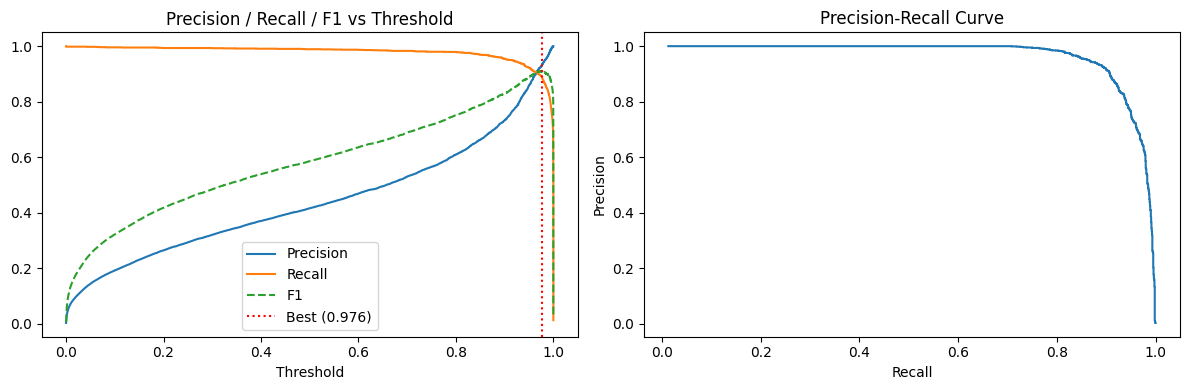


=== XGBoost with Calibrated Threshold ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.93      0.89      0.91      1643

    accuracy                           1.00    554082
   macro avg       0.97      0.95      0.96    554082
weighted avg       1.00      1.00      1.00    554082



In [19]:
y_prob = xgb.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# F1 for every threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'Best threshold: {best_threshold:.4f}')
print(f'F1 at best threshold: {best_f1:.4f}')
print(f'Precision: {precisions[best_idx]:.4f}')
print(f'Recall:    {recalls[best_idx]:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thresholds, precisions[:-1], label='Precision')
axes[0].plot(thresholds, recalls[:-1], label='Recall')
axes[0].plot(thresholds, f1_scores, label='F1', linestyle='--')
axes[0].axvline(best_threshold, color='red', linestyle=':', label=f'Best ({best_threshold:.3f})')
axes[0].set_xlabel('Threshold')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].legend()

axes[1].plot(recalls[:-1], precisions[:-1])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

# Final results with calibrated threshold
y_pred_best = (y_prob >= best_threshold).astype(int)
print('\n=== XGBoost with Calibrated Threshold ===')
print(classification_report(y_test, y_pred_best))

In [21]:
# ── Manual Test Cases ─────────────────────────────────────────────────────

def test_transaction(transaction_type, amount_inr, oldbalanceOrg_inr,
                     newbalanceOrig_inr, oldbalanceDest_inr,
                     newbalanceDest_inr, step):

    # Rule 1: Short circuit
    if transaction_type not in ['TRANSFER', 'CASH_OUT']:
        print(f"Type: {transaction_type} | Result: LEGITIMATE (Rule 1 — short circuit)")
        return

    # Rule 2: Balance reconciliation
    tolerance          = 1.0
    balance_check_orig = abs((oldbalanceOrg_inr - amount_inr) - newbalanceOrig_inr)
    balance_check_dest = abs((newbalanceDest_inr - oldbalanceDest_inr) - amount_inr)

    if balance_check_orig <= tolerance and balance_check_dest <= tolerance:
        print(f"Type: {transaction_type} | Amount: ₹{amount_inr:,.0f} | "
              f"Result: LEGITIMATE (Rule 2 — balances reconcile)")
        return

    # ML Model
    input_data = {
        'step'                  : step,
        'amount'                : amount_inr,
        'oldbalanceOrg'         : oldbalanceOrg_inr,
        'newbalanceOrig'        : newbalanceOrig_inr,
        'oldbalanceDest'        : oldbalanceDest_inr,
        'newbalanceDest'        : newbalanceDest_inr,
        'type_CASH_OUT'         : 1 if transaction_type == 'CASH_OUT' else 0,
        'type_TRANSFER'         : 1 if transaction_type == 'TRANSFER' else 0,
    }

    input_df    = pd.DataFrame([input_data])[X_train.columns]
    probability = xgb.predict_proba(input_df)[0][1]
    prediction  = 'FRAUD' if probability >= best_threshold else 'LEGITIMATE'

    print(f"Type: {transaction_type} | Amount: ₹{amount_inr:,.0f} | "
      f"Prob: {probability:.4f} | Result: {prediction}")

print("=" * 80)
print("TEST CASES")
print("=" * 80)

# Test 1: Small legitimate transfer
print("\n1. Small legitimate transfer:")
test_transaction('TRANSFER', 1000, 8000, 7000, 1000, 2000, 494)

# Test 2: Large legitimate transfer
print("\n2. Large legitimate transfer:")
test_transaction('TRANSFER', 500000, 1000000, 500000, 200000, 700000, 200)

# Test 3: TRANSFER fraud — sender drained, receiver unchanged
print("\n3. TRANSFER fraud:")
test_transaction('TRANSFER', 500000, 500000, 0, 200000, 200000, 300)

# Test 4: CASH_OUT fraud
print("\n4. CASH_OUT fraud:")
test_transaction('CASH_OUT', 200000, 200000, 0, 0, 0, 150)

# Test 5: CASH_IN short circuit
print("\n5. CASH_IN:")
test_transaction('CASH_IN', 5000, 1000, 6000, 0, 0, 100)

# Test 6: Legitimate CASH_OUT
print("\n6. Legitimate CASH_OUT:")
test_transaction('CASH_OUT', 10000, 50000, 40000,0, 10000, 400)

# Test 7: PAYMENT short circuit
print("\n7. PAYMENT:")
test_transaction('PAYMENT', 2000, 10000, 8000, 0, 2000, 50)

TEST CASES

1. Small legitimate transfer:
Type: TRANSFER | Amount: ₹1,000 | Result: LEGITIMATE (Rule 2 — balances reconcile)

2. Large legitimate transfer:
Type: TRANSFER | Amount: ₹500,000 | Result: LEGITIMATE (Rule 2 — balances reconcile)

3. TRANSFER fraud:
Type: TRANSFER | Amount: ₹500,000 | Prob: 0.2617 | Result: LEGITIMATE

4. CASH_OUT fraud:
Type: CASH_OUT | Amount: ₹200,000 | Prob: 0.7803 | Result: LEGITIMATE

5. CASH_IN:
Type: CASH_IN | Result: LEGITIMATE (Rule 1 — short circuit)

6. Legitimate CASH_OUT:
Type: CASH_OUT | Amount: ₹10,000 | Result: LEGITIMATE (Rule 2 — balances reconcile)

7. PAYMENT:
Type: PAYMENT | Result: LEGITIMATE (Rule 1 — short circuit)


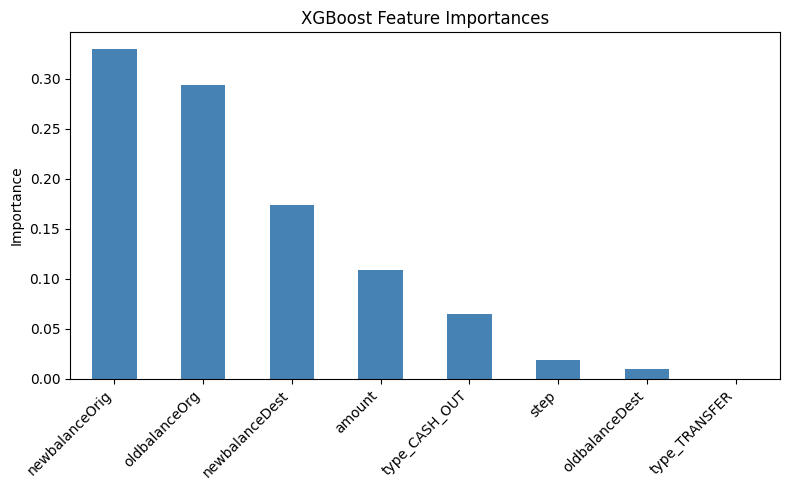

Feature importances:
newbalanceOrig    0.330133
oldbalanceOrg     0.294430
newbalanceDest    0.173733
amount            0.109143
type_CASH_OUT     0.064531
step              0.018711
oldbalanceDest    0.009318
type_TRANSFER     0.000000
dtype: float32

errorBalanceOrig and errorBalanceDest should appear near the top


In [22]:
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('XGBoost Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Feature importances:')
print(feat_imp)
print('\nFeature importance chart complete')

In [24]:
# Save model
with open('fraud_detection_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)
print('Model saved: fraud_detection_model.pkl')

# Save feature columns — MUST match exactly what the backend sends
feature_columns = X_train.columns.tolist()
with open('feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)
print('Feature columns saved:', feature_columns)

# -------------------------------------------------------------------------
# FIX 3: Save calibrated threshold so backend config loads it dynamically
# instead of using a hard-coded guess
# -------------------------------------------------------------------------
threshold_data = {
    'fraud_threshold':       round(float(best_threshold), 4),
    'high_risk_threshold':   round(min(float(best_threshold) + 0.25, 0.95), 4),
    'medium_risk_threshold': round(min(float(best_threshold) + 0.10, 0.90), 4)
}
with open('thresholds.json', 'w') as f:
    json.dump(threshold_data, f, indent=2)
print('Thresholds saved:', threshold_data)

# Download all three
from google.colab import files
files.download('fraud_detection_model.pkl')
files.download('feature_columns.json')
files.download('thresholds.json')

Model saved: fraud_detection_model.pkl
Feature columns saved: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_CASH_OUT', 'type_TRANSFER']
Thresholds saved: {'fraud_threshold': 0.976, 'high_risk_threshold': 0.95, 'medium_risk_threshold': 0.9}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>